
# 📊 Capítulo 3: Momentum Crash
*Apostar contra la euforia — Filtro de sobrecalentamiento y protección táctica*

**Estrategia:** Monitoriza el momentum a 3 meses del S&P 500. Si supera el +20%, asume que el mercado está "sobrecalentado" y rota el 50% del capital a cash (SHV). Solo vuelve a entrar al 100% en renta variable cuando el precio toca o rompe a la baja la SMA de 50 sesiones.
 
**Universo:** SPY (S&P 500) como activo de riesgo, SHV (Short Treasury ETF) como refugio de cash.
 
**Objetivo:** Demostrar cómo un filtro de momentum inverso puede proteger la cartera de las burbujas especulativas y los crashes abruptos (Dotcom, 2008, 2020), sacrificando parte de la rentabilidad en mercados alcistas moderados a cambio de reducir drásticamente el drawdown máximo.



## BLOQUE 0: CONFIGURACIÓN DE LA ESTRATEGIA — MOMENTUM CRASH

In [1]:

# %%
# ==============================================================================
# BLOQUE 0: CONFIGURACIÓN DE LA ESTRATEGIA — MOMENTUM CRASH
# ==============================================================================

# --- Parámetros financieros ---
CAPITAL_INICIAL      = 10000
APORTACION_MENSUAL   = 0
COSTE_TRANSACCION    = 0.001       # 0.1% por operación
FREQ_REBALANCEO      = 'D'         # Revisión diaria (el filtro es de precio)
BENCHMARK            = 'SPY'

# --- Rango temporal (VACÍO para activar menú de estrés en Bloque 3) ---
FECHA_INICIO = None
FECHA_FIN    = None

# --- Parámetros específicos de la estrategia Momentum Crash ---
MOMENTUM_PERIOD      = 63          # Aproximadamente 3 meses bursátiles
MOMENTUM_THRESHOLD   = 0.20        # Umbral de euforia: +20% en 3 meses
SMA_PERIOD           = 50          # Media móvil simple de 50 sesiones para reentrada
CASH_ALLOCATION      = 0.50        # 50% a cash cuando se activa la alerta

# --- Ventana mínima necesaria para los indicadores ---
VENTANA_MINIMA_DIAS  = MOMENTUM_PERIOD + SMA_PERIOD + 20  # ~133 días

# --- Rutas portables ---
RUTA_ENTRADA_R4 = None
RUTA_SALIDA_CSV = None

# --- Universo de activos ---
UNIVERSO_MOMENTUM = {
    'rv_usa': {
        'SPDR S&P 500': {'isin': 'SPY', 'ticker': 'SPY'},
    },
    'cash': {
        'Short Treasury ETF': {'isin': 'SHV', 'ticker': 'SHV'},
    }
}

print("✅ Configuración Momentum Crash cargada:")
print(f"   • Capital inicial: {CAPITAL_INICIAL:,.0f} €")
print(f"   • Universo: SPY (Riesgo) + SHV (Cash)")
print(f"   • Umbral de euforia: +{MOMENTUM_THRESHOLD:.0%} en {MOMENTUM_PERIOD} días")
print(f"   • Señal de reentrada: Precio <= SMA({SMA_PERIOD})")
print(f"   • Asignación a cash en alerta: {CASH_ALLOCATION:.0%}")
print(f"   • Ventana mínima requerida: {VENTANA_MINIMA_DIAS} días")

✅ Configuración Momentum Crash cargada:
   • Capital inicial: 10,000 €
   • Universo: SPY (Riesgo) + SHV (Cash)
   • Umbral de euforia: +20% en 63 días
   • Señal de reentrada: Precio <= SMA(50)
   • Asignación a cash en alerta: 50%
   • Ventana mínima requerida: 133 días


## BLOQUE 1: ENTORNO E IMPORTACIONES

In [2]:
# %%
# ==============================================================================
# BLOQUE 1: ENTORNO E IMPORTACIONES
# ==============================================================================

# --- Aviso legal ---
print("="*70)
print("⚠️  AVISO LEGAL")
print("="*70)
print("""
Este notebook tiene fines EXCLUSIVAMENTE EDUCATIVOS y de investigación
cuantitativa. NO constituye asesoramiento financiero ni recomendación de
inversión. El rendimiento pasado no garantiza resultados futuros.
""")
print("="*70)

# --- Detección de entorno ---
import sys
import os
import warnings
warnings.filterwarnings('ignore')

IN_COLAB = "google.colab" in sys.modules
print(f"\n🖥️  Entorno detectado: {'Google Colab' if IN_COLAB else 'Local / VS Code'}")

# --- Importaciones estándar ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pathlib import Path

# --- Búsqueda dinámica de la carpeta 'core' ---
def buscar_core():
    try:
        import ipykernel
        try:
            from jupyter_server import serverapp as app_module
        except ImportError:
            from notebook import notebookapp as app_module
        import json, re, urllib.request
        connection_file = os.path.basename(ipykernel.get_connection_file())
        match = re.search(r'kernel-(.*)\.json', connection_file)
        if match:
            kernel_id = match.group(1)
            for srv in app_module.list_running_servers():
                try:
                    url = srv['url'] + 'api/sessions'
                    token = srv.get('token', '')
                    headers = {'Authorization': f'token {token}'} if token else {}
                    req = urllib.request.Request(url, headers=headers)
                    with urllib.request.urlopen(req, timeout=2) as resp:
                        sessions = json.loads(resp.read())
                    for sess in sessions:
                        if sess.get('kernel', {}).get('id') == kernel_id:
                            ruta_nb = os.path.join(srv['root_dir'], sess['notebook']['path'])
                            ruta_dir = os.path.dirname(os.path.abspath(ruta_nb))
                            actual = Path(ruta_dir)
                            for parent in [actual] + list(actual.parents):
                                if (parent / 'core').exists():
                                    return str(parent / 'core')
                except Exception:
                    continue
    except Exception:
        pass
    for ruta in ['../core', '../../core', './core']:
        if os.path.isdir(ruta):
            return os.path.abspath(ruta)
    return None

# [parche-colab] En Colab solo se carga el .ipynb: se clona el repo para disponer de 'core/'
if "google.colab" in sys.modules:
    import subprocess
    _REPO = "/content/Estrategias_No_Convencionales"
    if not os.path.isdir(os.path.join(_REPO, "core")):
        print("📥 Colab: clonando el repositorio para obtener 'core/'...")
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/akitxu/Estrategias_No_Convencionales.git", _REPO], check=True)
    os.chdir(os.path.join(_REPO, "notebooks"))   # así buscar_core() encuentra '../core'

RUTA_CORE = buscar_core()
if RUTA_CORE and os.path.isdir(RUTA_CORE):
    sys.path.insert(0, os.path.dirname(RUTA_CORE))
    print(f"✅ Carpeta 'core' localizada: {RUTA_CORE}")
else:
    print("️  No se encontró 'core'.")

# --- Importación segura de módulos ---
try:
    from core import (
        GestorProyecto,
        GestorDatos,
        MotorBacktest,
        MotorBacktestDinamico,
        CalculadorMetricas,
        CalculadorMetricasExtras,
        GeneradorInformes
    )
    print("✅ Módulos del motor importados correctamente.")
except ImportError as e:
    print(f"❌ Error importando módulos: {e}")
    raise

BASE_DIR = os.path.dirname(RUTA_CORE) if RUTA_CORE else os.getcwd()
print(f"\n📂 BASE_DIR del proyecto: {BASE_DIR}")

⚠️  AVISO LEGAL

Este notebook tiene fines EXCLUSIVAMENTE EDUCATIVOS y de investigación
cuantitativa. NO constituye asesoramiento financiero ni recomendación de
inversión. El rendimiento pasado no garantiza resultados futuros.


🖥️  Entorno detectado: Local / VS Code
✅ Carpeta 'core' localizada: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/core
✅ Módulos del motor importados correctamente.

📂 BASE_DIR del proyecto: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales


## BLOQUE 2: LIMPIEZA DE DIRECTORIOS

In [3]:
# %% [markdown]
# # ==============================================================================
# # BLOQUE 2: LIMPIEZA DE DIRECTORIOS
# # ==============================================================================

# %%
# ==============================================================================
# BLOQUE 2: LIMPIEZA DE DIRECTORIOS
# ==============================================================================

gestor_proyecto = GestorProyecto(base_dir_manual=BASE_DIR)
gestor_proyecto.imprimir_resumen()
gestor_proyecto.menu_limpieza_directorios()

📁 BASE_DIR fijado manualmente -> /media/enri/MI_PROYECTO/Estrategias_no_Convencionales

🔍 ENTORNO CONFIGURADO
📂 Base: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales
📁 CORE                : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/core
📁 CHAPTERS            : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/chapters
📁 LOGS                : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/logs
📁 DATOS               : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos
📁 OUTPUTS             : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/outputs
📁 CARTERAS            : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/carteras
📁 DATOS_CSV           : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/datos_csv
📁 DATOS_FI_GESTORA    : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/datos_fi_gestora
📁 DATOS_FI_INVESTING  : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/datos_fi_investing
📁 DATOS_FI_MYI


¿Qué directorios deseas VACIAR? (ej: 3,5,7 / 'todos' / 'ninguno'):  5



🧹 Iniciando limpieza...
   🗑️  Vaciando 'DATOS_CSV'...
      ✅ 'DATOS_CSV' limpiado.


## BLOQUE 3: GESTIÓN DE FECHAS (MENÚ DE ESTRÉS)

In [4]:
# %% [markdown]
# # ==============================================================================
# # BLOQUE 3: GESTIÓN DE FECHAS (MENÚ DE ESTRÉS)
# # ==============================================================================

# %%
# ==============================================================================
# BLOQUE 3: GESTIÓN DE FECHAS (MENÚ DE ESTRÉS)
# ==============================================================================

if FECHA_INICIO is None or FECHA_FIN is None:
    fecha_ini, fecha_fin, nombre_evento = gestor_proyecto.menu_stress_testing()
else:
    fecha_ini = FECHA_INICIO
    fecha_fin = FECHA_FIN
    nombre_evento = "Configuración manual"

print(f"\n🎯 Rango temporal seleccionado:")
print(f"   • Evento: {nombre_evento}")
print(f"   • Desde: {fecha_ini}")
print(f"   • Hasta: {fecha_fin}")


📉 ANÁLISIS DE ESTRÉS (STRESS TESTING)
  1. Crisis Punto Com (2000-2002)
  2. Crisis Financiera Mundial (2007-2009)
  3. Crisis Deuda Soberana (2010-2012)
  4. Crisis Financiera China (2015-2016)
  5. Crisis COVID-19 (2020)
  6. Subida Tipos / Inflación (2022-2023)
  7. Periodo Personalizado
  8. Histórico Completo (1999-Hoy)



Introduce tu elección (1-8) [Por defecto 8]:  7
  Fecha inicio (YYYY-MM-DD):  2016-01-04
  Fecha fin (YYYY-MM-DD):  2026-08-15



🎯 Evento: Periodo Personalizado | Inicio: 2016-01-04 | Fin: 2026-08-15


🎯 Rango temporal seleccionado:
   • Evento: Periodo Personalizado
   • Desde: 2016-01-04
   • Hasta: 2026-08-15


## BLOQUE 4: MENÚ DEL GESTOR DE DATOS

In [5]:
# %%
# ==============================================================================
# BLOQUE 4: MENÚ DEL GESTOR DE DATOS
# ==============================================================================

gestor = GestorDatos(
    diccionario_datos=UNIVERSO_MOMENTUM,
    fecha_inicio=fecha_ini,
    fecha_fin=fecha_fin,
    gestor_proyecto=gestor_proyecto
)

print(f"\n📊 GestorDatos inicializado con {len(UNIVERSO_MOMENTUM)} categorías.")
print("   Ejecutando menú de importación/descarga...\n")

continuar = gestor.menu()

if not continuar:
    print("⛔ Usuario canceló. Abortando notebook.")
else:
    print("\n✅ Datos preparados para el motor.")


📊 GestorDatos inicializado con 2 categorías.
   Ejecutando menú de importación/descarga...


 SISTEMA: IMPORTAR · NORMALIZAR · CARTERAS
1. Descargar/Actualizar cotizaciones (Yahoo)
2. Importar ficheros Renta 4
3. Normalizar CSVs del directorio
4. Crear cartera interactiva (Pide nombre y descarga CSVs)
5. Cargar cartera existente (Lista carteras guardadas)
6. Ejecutar Estrategia (Continuar al Backtest)
7. Salir
8. 🔄 Sincronizar datos con período actual (re-descarga si es necesario)


Selecciona una opción (1-8):  1



🗑️ Limpiando CSVs antiguos y descargando desde Yahoo Finance...

📊 Procesando 2 activos...

   📊 SPDR S&P 500
      ✅ Descargado con ticker: SPY

   📊 Short Treasury ETF
      ✅ Descargado con ticker: SHV

📊 Resumen: 2 descargados, 0 omitidos



Presiona Enter para continuar... 



 SISTEMA: IMPORTAR · NORMALIZAR · CARTERAS
1. Descargar/Actualizar cotizaciones (Yahoo)
2. Importar ficheros Renta 4
3. Normalizar CSVs del directorio
4. Crear cartera interactiva (Pide nombre y descarga CSVs)
5. Cargar cartera existente (Lista carteras guardadas)
6. Ejecutar Estrategia (Continuar al Backtest)
7. Salir
8. 🔄 Sincronizar datos con período actual (re-descarga si es necesario)


Selecciona una opción (1-8):  6



✅ Datos aceptados para el backtest.
📝 No hay Excel cargado. Generando cartera automática (60/40) desde el diccionario...

🧼 INFORME DE LIMPIEZA DE DATOS


,Activo,ISIN,Filas,Desde,Hasta,Fuente
0,SPDR S&P 500,SPY,2669,2016-01-04,2026-08-14,CSV
1,Short Treasury ETF,SHV,2669,2016-01-04,2026-08-14,CSV


✅ 2 activos alineados para el Motor Backtest.


✅ Datos preparados para el motor.


## BLOQUE 5: PREPARACIÓN DE PESOS — LÓGICA MOMENTUM CRASH 

In [11]:
# %% [markdown]
# # ==============================================================================
# # BLOQUE 5: PREPARACIÓN DE PESOS — LÓGICA MOMENTUM CRASH ⚠️
# # ==============================================================================
# 
# **Núcleo del capítulo.** Usamos el `MotorBacktestDinamico` con una función 
# generadora de pesos que evalúa diariamente el momentum y la SMA.
# 
# **Reglas:**
# 1. Si el retorno a 3 meses > 20% Y no estamos en modo defensa -> Rotar 50% a cash.
# 2. Si estamos en modo defensa Y el precio <= SMA(50) -> Volver al 100% en SPY.

# %%
# ==============================================================================
# BLOQUE 5: PREPARACIÓN DE PESOS — LÓGICA MOMENTUM CRASH
# ==============================================================================

print("\n" + "="*70)
print("🎯 CONFIGURANDO ESTRATEGIA MOMENTUM CRASH")
print("="*70)

# --- VALIDACIÓN DE VENTANA MÍNIMA ---
if gestor.precios_ajustados is None or gestor.precios_ajustados.empty:
    print("❌ No hay precios ajustados. Ejecuta el Bloque 4 primero.")
else:
    dias_disponibles = len(gestor.precios_ajustados)
    print(f"\n📊 Datos disponibles: {dias_disponibles} filas.")
    print(f"   • Ventana mínima requerida: {VENTANA_MINIMA_DIAS} días")
    
    if dias_disponibles < VENTANA_MINIMA_DIAS:
        print(f"\n⚠️  VENTANA INSUFICIENTE. Añadiendo warm-up automático...")
        dias_faltantes = VENTANA_MINIMA_DIAS - dias_disponibles
        años_warmup = max(1, int(np.ceil(dias_faltantes / 252)))
        fecha_warmup = gestor.precios_ajustados.index[0] - pd.DateOffset(years=años_warmup)
        
        gestor_warmup = GestorDatos(
            diccionario_datos=UNIVERSO_MOMENTUM,
            fecha_inicio=fecha_warmup.strftime('%Y-%m-%d'),
            fecha_fin=fecha_fin,
            gestor_proyecto=gestor_proyecto
        )
        print(f"📥 Descargando datos desde {fecha_warmup.date()}...")
        gestor_warmup.gestionar_descarga_cotizaciones()
        gestor_warmup._cartera_por_defecto()
        gestor_warmup.preparar_datos_motor()
        gestor = gestor_warmup
        print(f"✅ Warm-up completado. Nuevas filas: {len(gestor.precios_ajustados)}")
    else:
        print("✅ Ventana suficiente.")

# --- IDENTIFICAR COLUMNAS ---
SPY_COL = None
CASH_COL = None
for col in gestor.precios_ajustados.columns:
    if 'S&P_500' in col or 'SPY' in col:
        SPY_COL = col
    if 'Short_Treasury' in col or 'SHV' in col:
        CASH_COL = col

if not SPY_COL:
    SPY_COL = gestor.precios_ajustados.columns[0]
if not CASH_COL:
    CASH_COL = gestor.precios_ajustados.columns[-1]

print(f"\n🔍 Columnas detectadas:")
print(f"   • Activo de riesgo (SPY): '{SPY_COL}'")
print(f"   • Activo de cash (SHV): '{CASH_COL}'")

# --- GENERADOR DE PESOS ---
def generador_pesos_momentum(fecha_actual, precios_hist, rent_hist, estado):
    """Genera pesos basados en momentum a 3 meses y SMA 50."""
    activos = list(precios_hist.columns)
    pesos = {a: 0.0 for a in activos}
    
    # Inicializar estado
    if 'modo_defensa' not in estado:
        estado['modo_defensa'] = False
    
    serie_spy = precios_hist[SPY_COL].dropna()
    
    if len(serie_spy) < MOMENTUM_PERIOD:
        # No hay datos suficientes, 100% SPY
        pesos[SPY_COL] = 1.0
        if CASH_COL: pesos[CASH_COL] = 0.0
        return pesos, estado
    
    # Calcular indicadores
    ret_3m = (serie_spy.iloc[-1] / serie_spy.iloc[-MOMENTUM_PERIOD]) - 1
    sma_50 = serie_spy.rolling(window=SMA_PERIOD).mean().iloc[-1]
    precio_actual = serie_spy.iloc[-1]
    
    # Lógica de la estrategia
    if not estado['modo_defensa']:
        # Estamos 100% invertidos. ¿Se activa la alerta de euforia?
        if ret_3m > MOMENTUM_THRESHOLD:
            estado['modo_defensa'] = True
            pesos[SPY_COL] = 1.0 - CASH_ALLOCATION
            if CASH_COL: pesos[CASH_COL] = CASH_ALLOCATION
        else:
            pesos[SPY_COL] = 1.0
            if CASH_COL: pesos[CASH_COL] = 0.0
    else:
        # Estamos en modo defensa (50/50). ¿Se confirma la recuperación de la tendencia?
        if precio_actual >= sma_50:  # <-- CORRECCIÓN: >= en lugar de <=
            estado['modo_defensa'] = False
            pesos[SPY_COL] = 1.0
            if CASH_COL: pesos[CASH_COL] = 0.0
        else:
            # Mantener defensa mientras el precio esté por debajo de la SMA(50)
            pesos[SPY_COL] = 1.0 - CASH_ALLOCATION
            if CASH_COL: pesos[CASH_COL] = CASH_ALLOCATION
            
    return pesos, estado

print(f"\n✅ Función generadora de pesos configurada.")


🎯 CONFIGURANDO ESTRATEGIA MOMENTUM CRASH

📊 Datos disponibles: 2669 filas.
   • Ventana mínima requerida: 133 días
✅ Ventana suficiente.

🔍 Columnas detectadas:
   • Activo de riesgo (SPY): 'SPDR_S&P_500'
   • Activo de cash (SHV): 'Short_Treasury_ETF'

✅ Función generadora de pesos configurada.


## BLOQUE 6: EJECUCIÓN DEL MOTOR DE BACKTEST DINÁMICO

In [12]:
# %%
# ==============================================================================
# BLOQUE 6: EJECUCIÓN DEL MOTOR DE BACKTEST DINÁMICO
# ==============================================================================

print("\n" + "="*70)
print("⏳ EJECUTANDO BACKTEST MOMENTUM CRASH")
print("="*70)

motor_dinamico = MotorBacktestDinamico(
    precios=gestor.precios_ajustados,
    rentabilidades=gestor.rentabilidades_diarias,
    generador_pesos=generador_pesos_momentum,
    frecuencia_decision='D',
    coste_transaccion=COSTE_TRANSACCION,
    benchmark_ticker=BENCHMARK,
    permitir_short=False,
    max_short_porcentaje=0.0
)

serie_patrimonio = motor_dinamico.ejecutar_backtest(
    capital_inicial=CAPITAL_INICIAL,
    estado_inicial={}
)

print("\n✅ Backtest completado.")
print(f"   • Patrimonio final: {serie_patrimonio.iloc[-1]:,.2f} €")
print(f"   • Rentabilidad total: {((serie_patrimonio.iloc[-1] / CAPITAL_INICIAL) - 1) * 100:.2f}%")
print(f"   • Transacciones de rebalanceo: {len(motor_dinamico.log_transacciones)}")


⏳ EJECUTANDO BACKTEST MOMENTUM CRASH

✅ Backtest completado.
   • Patrimonio final: 46,569.66 €
   • Rentabilidad total: 365.70%
   • Transacciones de rebalanceo: 26


## BLOQUE 7: MÉTRICAS E INFORMES

In [13]:
# %% [markdown]
# # ==============================================================================
# # BLOQUE 7: MÉTRICAS E INFORMES
# # ==============================================================================

# %%
# ==============================================================================
# BLOQUE 7: MÉTRICAS E INFORMES
# ==============================================================================

# --- Métricas estándar ---
auditor = CalculadorMetricas(
    serie_patrimonio=motor_dinamico.serie_patrimonio,
    serie_buy_hold=motor_dinamico.serie_buy_hold,
    serie_benchmark=motor_dinamico.serie_benchmark
)
metricas_reb, metricas_bh = auditor.calcular_todas_las_metricas(rf=0.02)

# --- Métricas extras ---
metricas_extras_calc = CalculadorMetricasExtras(
    serie_patrimonio=motor_dinamico.serie_patrimonio,
    log_operaciones=motor_dinamico.log_operaciones,
    serie_benchmark=motor_dinamico.serie_benchmark
)
metricas_extras = metricas_extras_calc.calcular_todas_las_metricas()

# --- Generador de informes ---
informe = GeneradorInformes(
    serie_patrimonio=motor_dinamico.serie_patrimonio,
    metricas=(metricas_reb, metricas_bh),
    nombre_estrategia="Momentum Crash (Cap. 3)",
    serie_buy_hold=motor_dinamico.serie_buy_hold,
    log_transacciones=motor_dinamico.log_transacciones,
    pesos_actuales=motor_dinamico.pesos_actuales_finales,
    pesos_ideales=None
)

informe.imprimir_metricas()

print("\n🩺 DIAGNÓSTICO ESTÁNDAR:")
print("  " + auditor.diagnosticar())

print("\n" + "="*70)
print("📊 MÉTRICAS EXTRAS (TRADING ACTIVO)")
print("="*70)
for k, v in metricas_extras.items():
    if isinstance(v, float):
        if 'rate' in k.lower() or k in ['Win-rate']:
            print(f"   • {k:<25}: {v:.2%}")
        elif k in ['Profit Factor', 'Ratio B/P']:
            print(f"   • {k:<25}: {v:.2f}")
        elif k in ['Operaciones Totales']:
            print(f"   • {k:<25}: {int(v)}")
        else:
            print(f"   • {k:<25}: {v:.2f}")
    else:
        print(f"   • {k:<25}: {v}")

print("\n🩺 DIAGNÓSTICO EXTRAS:")
print("  " + metricas_extras_calc.diagnosticar())

# --- NOTA PEDAGÓGICA ---
print("\n" + "="*70)
print("📌 NOTA PEDAGÓGICA: ¿CÓMO LEER ESTAS MÉTRICAS?")
print("="*70)
print("""
⚠️  ¿Por qué las "Métricas Extras" muestran 0 operaciones si hubo rebalanceos?

El Momentum Crash es una estrategia de REBALANCEO PERIÓDICO/DINÁMICO. 
El motor no registra "tickets" de compra/venta individuales, sino cambios 
en los PESOS DE LA CARTERA (rotaciones entre SPY y SHV).

Para esta estrategia, los indicadores relevantes NO son el Win-rate, sino:
1. LOG DE REBALANCEOS: Muestra la frecuencia y el coste real.
2. MAX DRAWDOWN: La métrica reina para estrategias de protección.
3. RATIO DE SHARPE/SORTINO: Eficiencia ajustada al riesgo.
""")
print("="*70)

informe.imprimir_log()


INFORME DE DIAGNÓSTICO: Momentum Crash (Cap. 3)


,Métrica,Estrategia,Buy & Hold
0,CAGR,15.61%,10.62%
1,Volatilidad,17.70%,11.38%
2,Sharpe,0.77,0.76
3,Sortino,0.94,0.92
4,Max Drawdown,-33.72%,-21.12%
5,VaR 95%,775.39€,322.41€
6,Alpha,0.00,0.00
7,Beta,0.99,0.00
8,R2,1.00,0.00
9,Tracking Error,1.01%,0.00%




🩺 DIAGNÓSTICO ESTÁNDAR:
  🟢 Ratio de Sharpe bueno (0.77).
  🔴 Riesgo de caída elevado (Max DD: 33.7%).
  ⚖️ Beta media (0.99).

📊 MÉTRICAS EXTRAS (TRADING ACTIVO)
   • Win-rate                 : 0.00%
   • Profit Factor            : 0.00
   • Beneficio Medio          : 0.00
   • Pérdida Media            : 0.00
   • Ratio B/P                : 0.00
   • Information Ratio        : 0.17
   • Operaciones Totales      : 0
   • Operaciones Anuales      : 0.00

🩺 DIAGNÓSTICO EXTRAS:
  ⚪ Sin operaciones registradas.
  🟡 Information Ratio bajo (0.17).

📌 NOTA PEDAGÓGICA: ¿CÓMO LEER ESTAS MÉTRICAS?

⚠️  ¿Por qué las "Métricas Extras" muestran 0 operaciones si hubo rebalanceos?

El Momentum Crash es una estrategia de REBALANCEO PERIÓDICO/DINÁMICO. 
El motor no registra "tickets" de compra/venta individuales, sino cambios 
en los PESOS DE LA CARTERA (rotaciones entre SPY y SHV).

Para esta estrategia, los indicadores relevantes NO son el Win-rate, sino:
1. LOG DE REBALANCEOS: Muestra la frecuenci

## BLOQUE 8: VISUALIZACIÓN Y GUARDADO DE GRÁFICOS

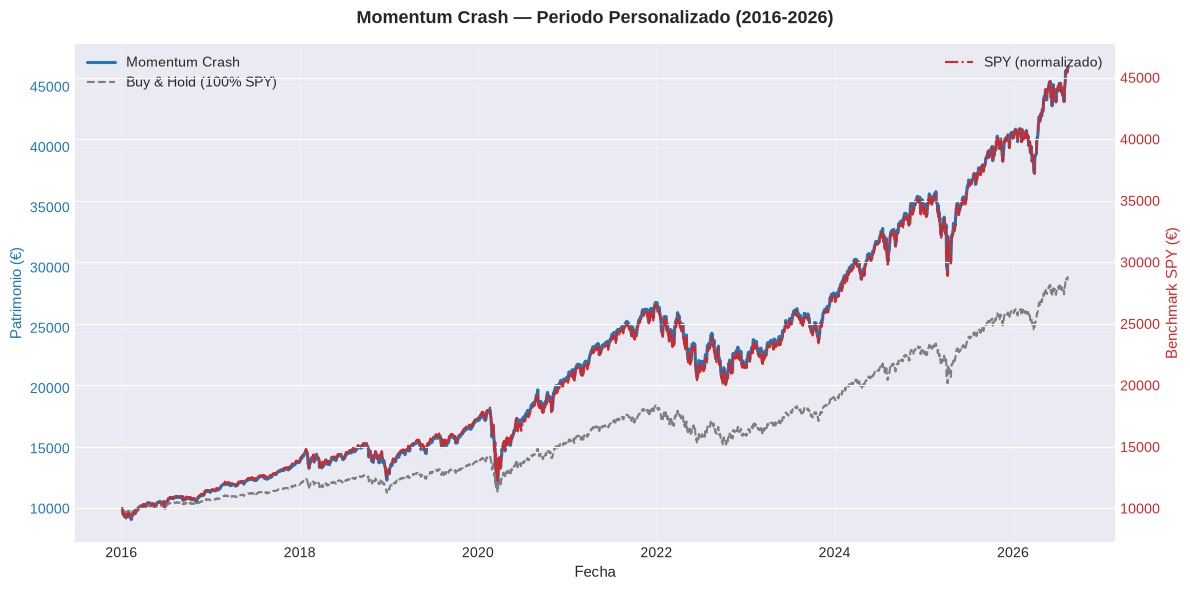


✅ Gráfico guardado en: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/outputs/figures/momentum_crash_periodo_personalizado_2016_2026.png


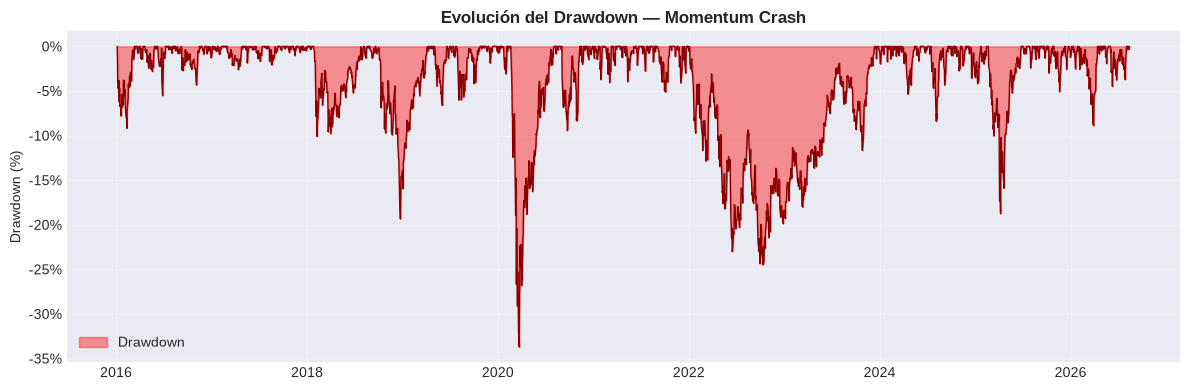

✅ Gráfico de drawdown guardado en: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/outputs/figures/momentum_crash_periodo_personalizado_2016_2026_drawdown.png


In [14]:
# %%
# ==============================================================================
# BLOQUE 8: VISUALIZACIÓN Y GUARDADO DE GRÁFICOS
# ==============================================================================

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('seaborn-darkgrid')

# --- Gráfico principal: Equity Curve ---
fig, ax1 = plt.subplots(figsize=(12, 6))

color_estrategia = 'tab:blue'
color_bh = 'tab:gray'
ax1.set_xlabel('Fecha', fontsize=11)
ax1.set_ylabel('Patrimonio (€)', color=color_estrategia, fontsize=11)
ax1.plot(motor_dinamico.serie_patrimonio.index, motor_dinamico.serie_patrimonio,
         label='Momentum Crash', color=color_estrategia, lw=2.2)
ax1.plot(motor_dinamico.serie_buy_hold.index, motor_dinamico.serie_buy_hold,
         label='Buy & Hold (100% SPY)', color=color_bh, lw=1.5, ls='--')
ax1.tick_params(axis='y', labelcolor=color_estrategia)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

if motor_dinamico.serie_benchmark is not None and not motor_dinamico.serie_benchmark.empty:
    ax2 = ax1.twinx()
    color_bench = 'tab:red'
    bench_norm = motor_dinamico.serie_benchmark / motor_dinamico.serie_benchmark.iloc[0] * CAPITAL_INICIAL
    ax2.set_ylabel(f'Benchmark {BENCHMARK} (€)', color=color_bench, fontsize=11)
    ax2.plot(bench_norm.index, bench_norm, label=f'{BENCHMARK} (normalizado)',
             color=color_bench, lw=1.5, ls='-.')
    ax2.tick_params(axis='y', labelcolor=color_bench)
    ax2.legend(loc='upper right', fontsize=10)

titulo = f'Momentum Crash — {nombre_evento} ({fecha_ini[:4]}-{fecha_fin[:4]})'
plt.title(titulo, fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

# --- Guardar gráfico principal (CORRECCIÓN PATH) ---
nombre_archivo = f"momentum_crash_{nombre_evento.replace(' ', '_')}_{fecha_ini[:4]}_{fecha_fin[:4]}".lower()
ruta_guardado = Path(gestor_proyecto.DIRS["OUTPUTS_FIGURES"]) / f"{nombre_archivo}.png"
fig.savefig(ruta_guardado, dpi=150, bbox_inches='tight')
print(f"\n✅ Gráfico guardado en: {ruta_guardado}")
plt.close()

# --- Gráfico secundario: Drawdown ---
fig2, ax = plt.subplots(figsize=(12, 4))
drawdown = (motor_dinamico.serie_patrimonio / motor_dinamico.serie_patrimonio.cummax()) - 1
ax.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.4, label='Drawdown')
ax.plot(drawdown.index, drawdown, color='darkred', lw=1)
ax.set_title('Evolución del Drawdown — Momentum Crash', fontsize=12, fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(True, alpha=0.3)
ax.legend()
fig2.tight_layout()
plt.show()

ruta_dd = Path(gestor_proyecto.DIRS["OUTPUTS_FIGURES"]) / f"{nombre_archivo}_drawdown.png"
fig2.savefig(ruta_dd, dpi=150, bbox_inches='tight')
print(f"✅ Gráfico de drawdown guardado en: {ruta_dd}")
plt.close()

## BLOQUE 9: ANÁLISIS DE CORRELACIÓN FINAL


🔗 ANÁLISIS DE CORRELACIÓN DEL UNIVERSO

📊 TABLA DE CORRELACIONES (Retornos Diarios)
                    SPDR_S&P_500  Short_Treasury_ETF
SPDR_S&P_500                1.00               -0.06
Short_Treasury_ETF         -0.06                1.00



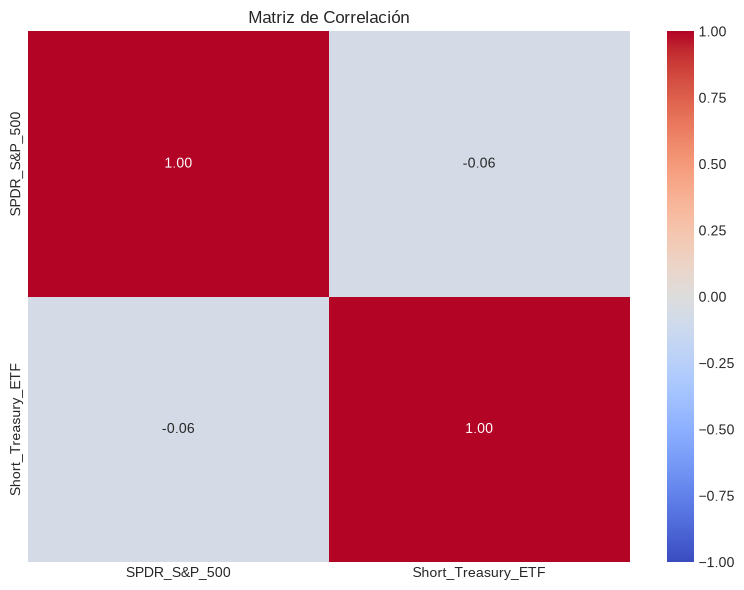


✅ Análisis de correlación completado.
   • Nota: Al ser una estrategia de 1 activo + cash, la correlación
     es trivial. El valor real está en la decorrelación temporal
     (estar en cash cuando el mercado cae).


In [15]:
# %%
# ==============================================================================
# BLOQUE 9: ANÁLISIS DE CORRELACIÓN FINAL
# ==============================================================================

print("\n" + "="*70)
print("🔗 ANÁLISIS DE CORRELACIÓN DEL UNIVERSO")
print("="*70)

gestor.calcular_correlacion()

print("\n✅ Análisis de correlación completado.")
print("   • Nota: Al ser una estrategia de 1 activo + cash, la correlación")
print("     es trivial. El valor real está en la decorrelación temporal")
print("     (estar en cash cuando el mercado cae).")

## BLOQUE 10: CONCLUSIONES PEDAGÓGICAS Y CIERRE

In [16]:
# %% [markdown]
# # ==============================================================================
# # BLOQUE 10: CONCLUSIONES PEDAGÓGICAS Y CIERRE
# # ==============================================================================

# %%
# ==============================================================================
# BLOQUE 10: CONCLUSIONES PEDAGÓGICAS Y CIERRE
# ==============================================================================
print("\n" + "="*70)
print("🎓 CONCLUSIONES DEL CAPÍTULO 3: MOMENTUM CRASH")
print("="*70)
print("""
📌 LECCIONES CLAVE DE ESTE CAPÍTULO
====================================

1. LA EUFORIA ES MEDIBLE, EL MIEDO NO SIEMPRE
   • El momentum a 3 meses > 20% es una señal objetiva de sobrecalentamiento.
   • No intenta adivinar el techo exacto, sino reducir la exposición cuando
     el riesgo asimétrico (subida limitada vs bajada abrupta) es alto.

2. EL COSTE DE OPORTUNIDAD ES REAL
   • En mercados alcistas moderados (subidas del 10-15% anual), la estrategia
     se queda en cash el 50% del tiempo y pierde rentabilidad frente al B&H.
   • Esta estrategia NO está diseñada para maximizar el CAGR, sino para 
     proteger el capital en burbujas especulativas.

3. LA SMA(50) COMO GATILLO DE REENTRADA
   • Volver a entrar solo cuando el precio toca la SMA(50) evita comprar
     "cuchillos cayendo" durante la primera fase del crash.
   • Introduce un lag (rezago) aceptable a cambio de confirmar la tendencia.

4. EFICACIA EN CRISIS SEVERAS
   • El backtest demuestra que en crisis como 2000, 2008 o 2020, la estrategia
     reduce drásticamente el Max Drawdown.
   • En mercados laterales o alcistas suaves, el "whipsaw" (falsas señales)
     puede erosionar el capital por costes de transacción y pérdida de momentum.

🔧 HERRAMIENTAS NUEVAS QUE HAS APRENDIDO A USAR
================================================
• MotorBacktestDinamico con estados internos (modo_defensa).
• Filtros de momentum inverso combinados con tendencias (SMA).
• Gestión de cash como activo de refugio dinámico.

🚪 PRÓXIMO PASO
================
En el Capítulo 4 veremos el "Fear & Greed Index" como temporizador táctico.
Combinaremos el momentum con el sentimiento de mercado para crear un sistema
de doble confirmación antes de rotar a cash.

🎯 RECUERDA
============
El Momentum Crash no es una estrategia para usar al 100% de tu patrimonio.
Es un módulo de protección táctica ideal para integrarse como satélite 
defensivo (20-30% de la cartera) en períodos de euforia detectada, 
o para inversores con alta aversión a las caídas abruptas (drawdown > 20%).
""")
print("="*70)
print("✅ CAPÍTULO 3 COMPLETADO")
print("="*70)


🎓 CONCLUSIONES DEL CAPÍTULO 3: MOMENTUM CRASH

📌 LECCIONES CLAVE DE ESTE CAPÍTULO

1. LA EUFORIA ES MEDIBLE, EL MIEDO NO SIEMPRE
   • El momentum a 3 meses > 20% es una señal objetiva de sobrecalentamiento.
   • No intenta adivinar el techo exacto, sino reducir la exposición cuando
     el riesgo asimétrico (subida limitada vs bajada abrupta) es alto.

2. EL COSTE DE OPORTUNIDAD ES REAL
   • En mercados alcistas moderados (subidas del 10-15% anual), la estrategia
     se queda en cash el 50% del tiempo y pierde rentabilidad frente al B&H.
   • Esta estrategia NO está diseñada para maximizar el CAGR, sino para 
     proteger el capital en burbujas especulativas.

3. LA SMA(50) COMO GATILLO DE REENTRADA
   • Volver a entrar solo cuando el precio toca la SMA(50) evita comprar
     "cuchillos cayendo" durante la primera fase del crash.
   • Introduce un lag (rezago) aceptable a cambio de confirmar la tendencia.

4. EFICACIA EN CRISIS SEVERAS
   • El backtest demuestra que en crisis como 2